In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Set aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
sns.set_palette("deep")

1. DATA LOADING & INITIAL INSPECTION

In [4]:
# Load data (ensure your dataframe 'df' is loaded as in the previous step)
df = pd.read_csv('Loan_default.csv')

In [7]:
# Basic Info
print("Dataset Shape:", df.shape)
print("\n--- Data Types & Missing Values ---")
print(df.info())

Dataset Shape: (255347, 19)

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   LoanID                  255347 non-null  object 
 1   Age                     255347 non-null  int64  
 2   Income                  255347 non-null  int64  
 3   LoanAmount              255347 non-null  int64  
 4   CreditScore             255347 non-null  int64  
 5   MonthsEmployed          255347 non-null  int64  
 6   NumCreditLines          255347 non-null  int64  
 7   InterestRate            255347 non-null  float64
 8   LoanTerm                255347 non-null  int64  
 9   DTIRatio                255347 non-null  float64
 10  Education               255347 non-null  object 
 11  EmploymentType          255347 non-null  object 
 12  MaritalStatus           255347 non-null  object 
 13  HasMortga

In [8]:
# Convert 'Default' to boolean/integer for calculation purposes if it's stored as string
if df['Default'].dtype == 'O':
    df['Default'] = df['Default'].map({'True': 1, 'False': 0, True: 1, False: 0})
elif df['Default'].dtype == 'bool':
    df['Default'] = df['Default'].astype(int)

### VISUAL 1: The Target Variable (Default Rate)

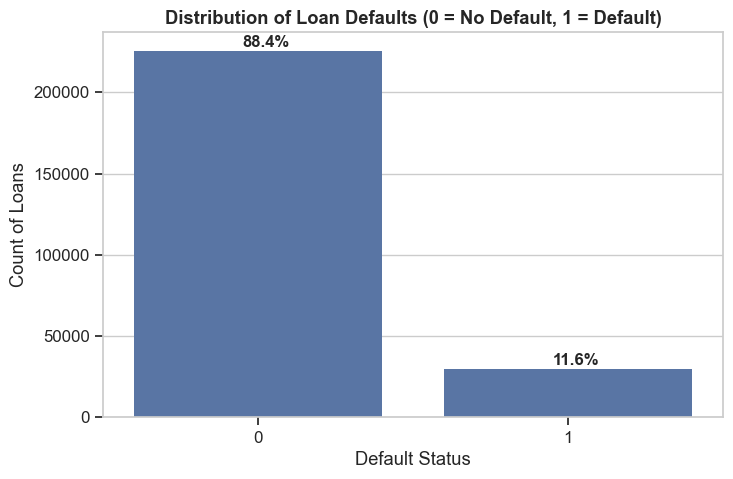

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Default', data=df)
plt.title('Distribution of Loan Defaults (0 = No Default, 1 = Default)', fontweight='bold')
plt.xlabel('Default Status')
plt.ylabel('Count of Loans')

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + (total*0.01)
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')
plt.show()

Questions Answered & Business Insights

1. Target Variable Distribution (Countplot)
Question: What is the overall default rate in our portfolio? Is our dataset severely imbalanced?

Insight: The overall default rate in our portfolio is 11.6% (represented by the 1 on the x-axis). This means that out of all the loans logged in this dataset, roughly 1 in every 9 borrowers has defaulted. Yes, the dataset is significantly imbalanced. An 88.4% to 11.6% split is a textbook example of a class imbalance, which is incredibly common in credit risk.

### VISUAL 2: Correlation Heatmap (Continuous Variables)

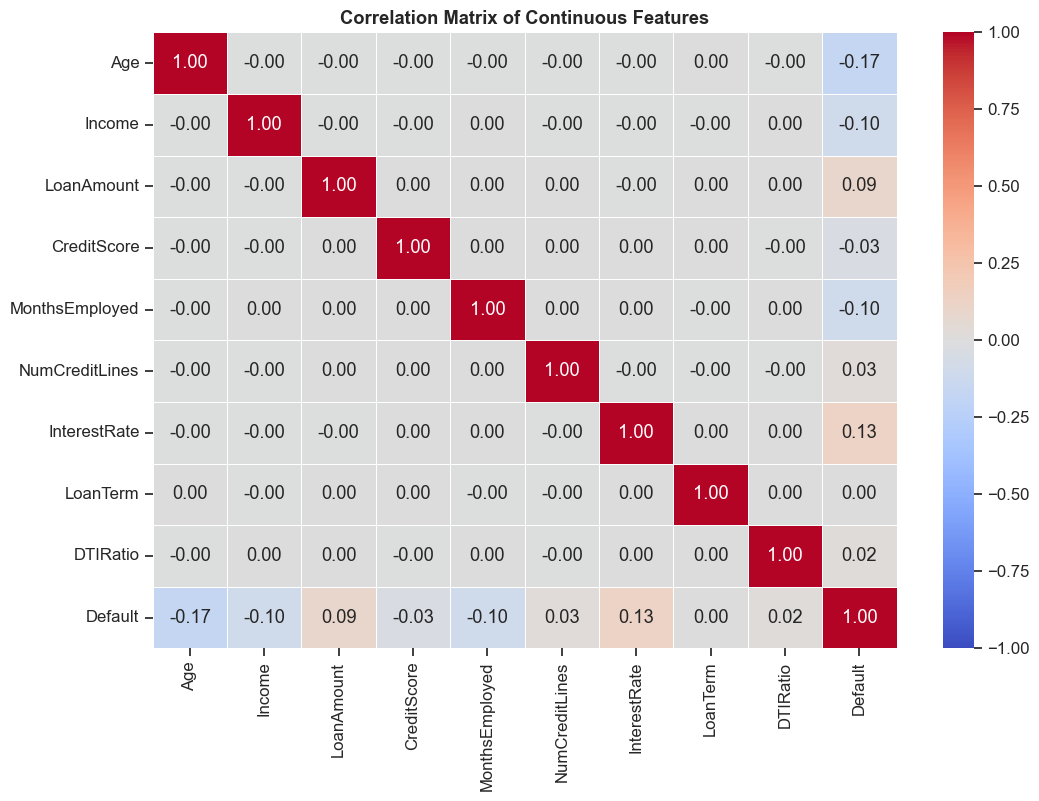

In [13]:
# Select numerical columns for correlation
numerical_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 
                  'MonthsEmployed', 'NumCreditLines', 'InterestRate', 
                  'LoanTerm', 'DTIRatio', 'Default']

plt.figure(figsize=(12, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Continuous Features', fontweight='bold')
plt.show()

Questions Answered & Business Insights

2. Correlation Heatmap
Question: Are there redundant features (multicollinearity) in our data? Which numerical variables have the strongest linear relationship with loan defaults?

Insight: Based on the correlation matrix, there is zero multicollinearity among the independent features (all non-diagonal correlations are essentially 0.00), meaning there are no redundant numerical variables.

When it comes to predicting loan defaults, Age has the strongest linear relationship at -0.17 (a negative correlation, meaning younger borrowers default slightly more often), followed closely by InterestRate at 0.13 (a positive correlation, meaning higher rates equal higher default risk). Overall, however, all linear relationships with default are quite weak, suggesting that non-linear machine learning models will be necessary to find stronger, more complex patterns

### VISUAL 3: Numerical Feature Distributions by Default

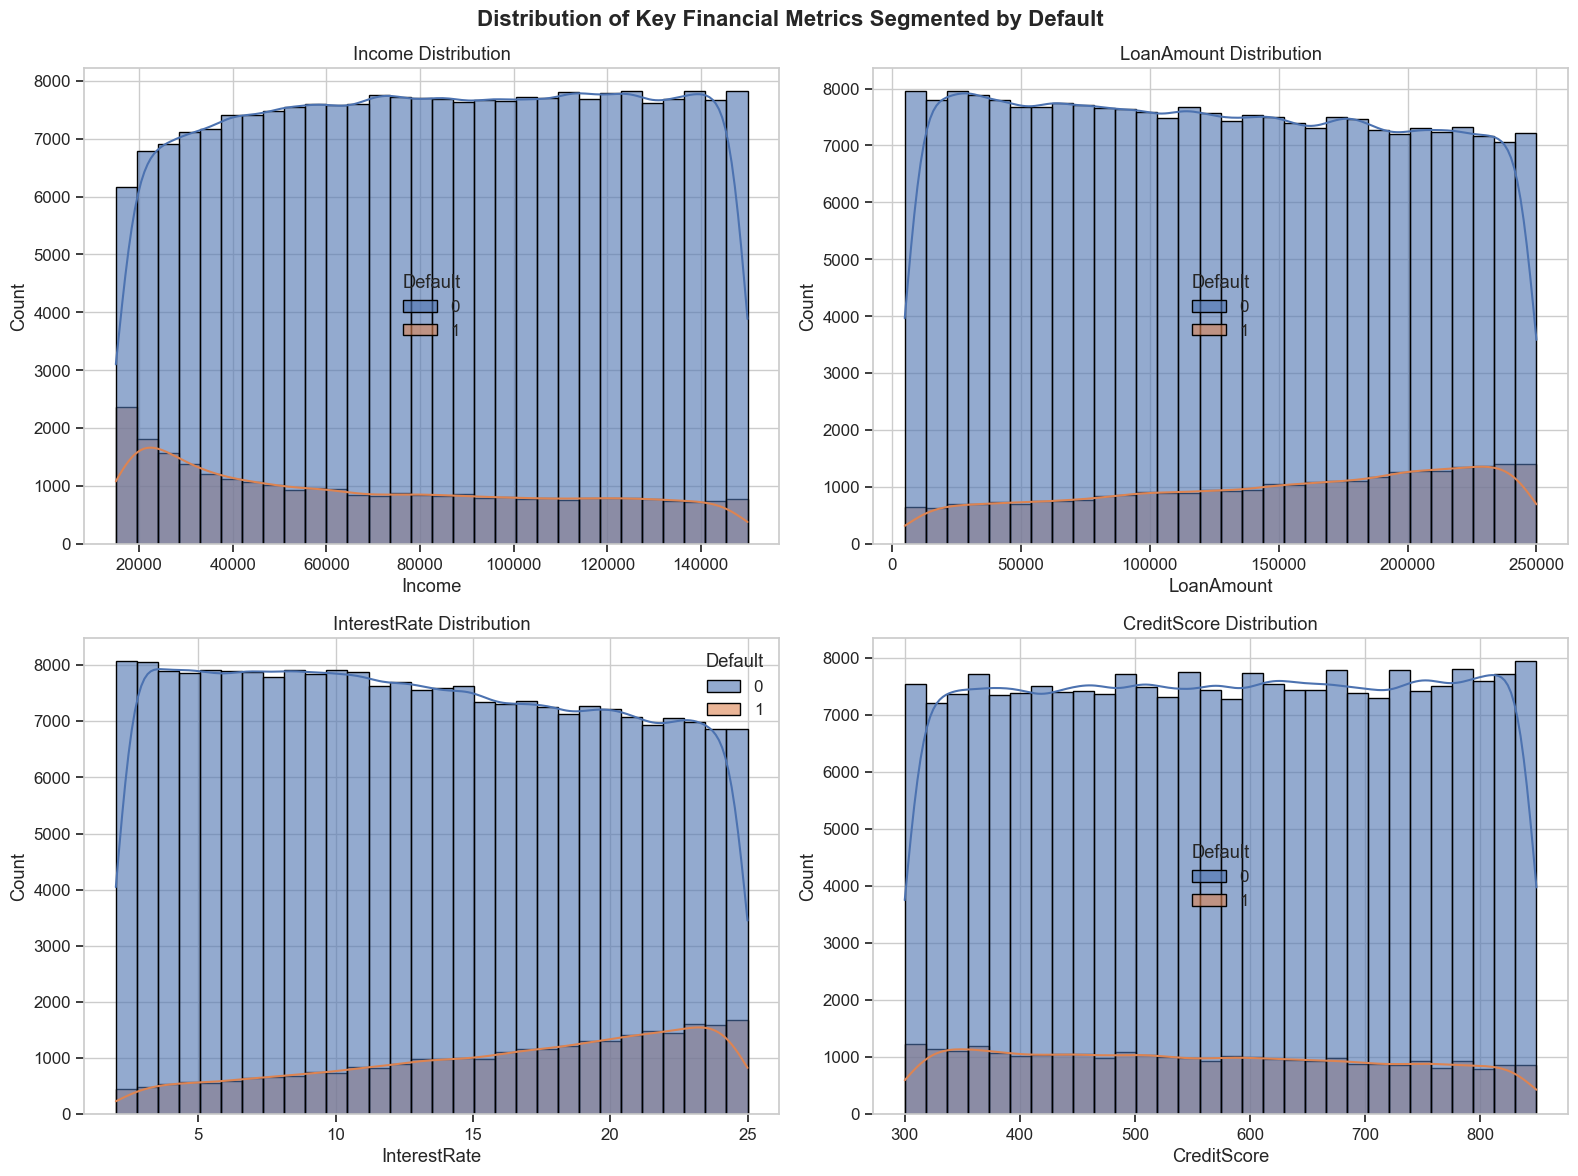

In [14]:
features_to_plot = ['Income', 'LoanAmount', 'InterestRate', 'CreditScore']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Key Financial Metrics Segmented by Default', fontsize=16, fontweight='bold')

for i, feature in enumerate(features_to_plot):
    row, col = divmod(i, 2)
    sns.histplot(data=df, x=feature, hue='Default', kde=True, bins=30, ax=axes[row, col], alpha=0.6)
    axes[row, col].set_title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

Questions Answered & Business Insights

3. Numerical Feature Distributions (Histograms + KDE)
Question: How does the distribution of income, loan amounts, credit scores, and interest rates differ between people who default and those who pay off their loans?

Insight: Across all four metrics, the distribution of non-defaulters (0) remains relatively uniform, while defaulters (1) display distinct shifts in risk behavior. Borrowers who default are heavily concentrated in lower-income brackets (skewed toward $20,000) and exhibit slightly lower credit scores. Conversely, defaults steadily rise as both the loan amount increases (peaking near $250,000) and interest rates climb (surging past 20%). This indicates that lower earning power combined with larger, high-interest debt significantly drives default behavior in our portfolio

### VISUAL 4: Categorical Drivers of Default

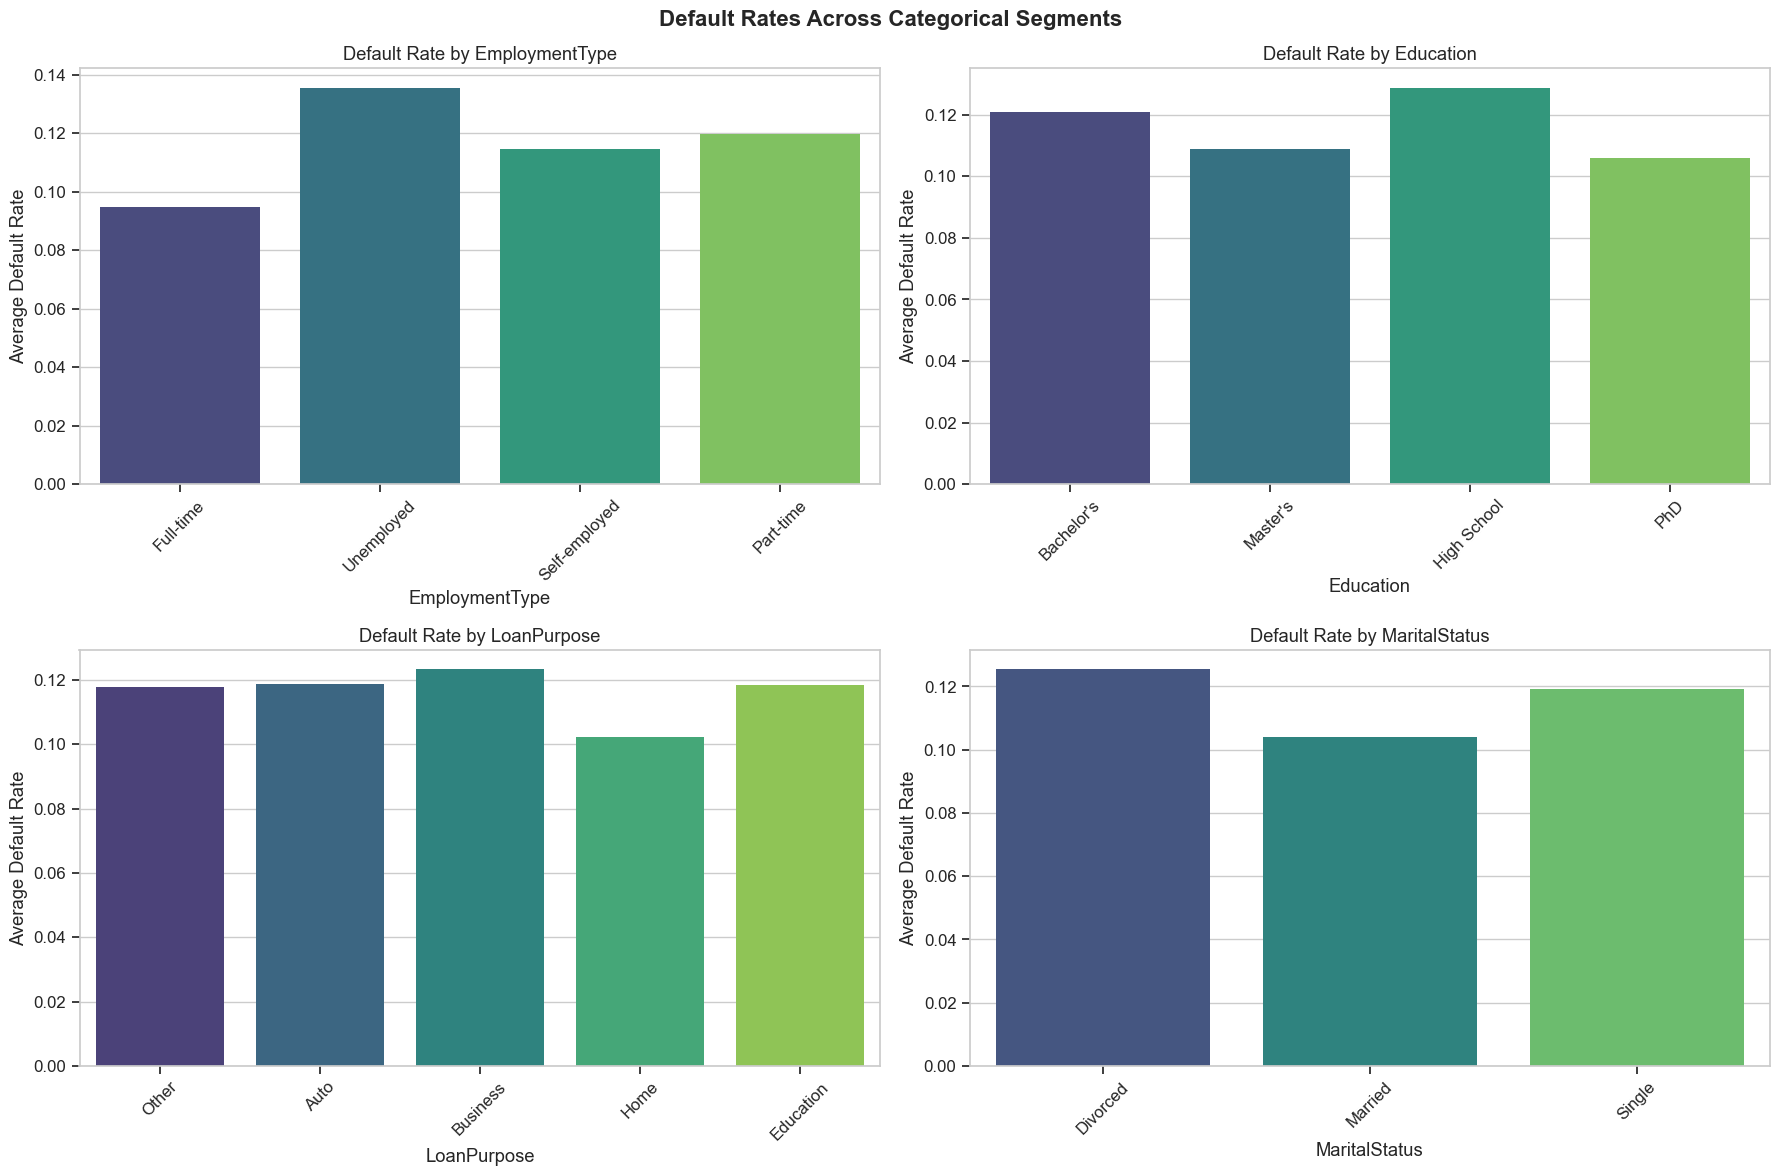

In [15]:
cat_features = ['EmploymentType', 'Education', 'LoanPurpose', 'MaritalStatus']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Default Rates Across Categorical Segments', fontsize=16, fontweight='bold')

for i, feature in enumerate(cat_features):
    row, col = divmod(i, 2)
    # Calculate mean default rate per category
    sns.barplot(x=feature, y='Default', data=df, ax=axes[row, col], errorbar=None, palette='viridis')
    axes[row, col].set_title(f'Default Rate by {feature}')
    axes[row, col].set_ylabel('Average Default Rate')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Questions Answered & Business Insights

4. Categorical Drivers (Bar Plots)
Question: Do specific demographics or loan criteria (Education, Employment Type, Loan Purpose) carry a significantly higher risk of default?

Insight :
Based on the bar plots, there are clear differences in risk across your categorical features, though most hover near the baseline:

* **Employment Type:** Unemployed applicants carry the highest risk of default (~13.5%), whereas full-time employed individuals are the safest segment (~9.5%).
* **Education:** Individuals with a High School education exhibit the highest default rate (~13%), while those with Master's degrees and PhDs show lower overall risk.
* **Loan Purpose:** Business loans pose the highest risk of default (~12.2%), whereas Home loans carry the lowest relative risk (~10.2%).
* **Marital Status:** Divorced applicants show a slightly elevated default rate (~12.5%) compared to married applicants, who represent the lowest-risk segment in this category (~10.5%).

### VISUAL 5: Risk Indicators (Boxplots)

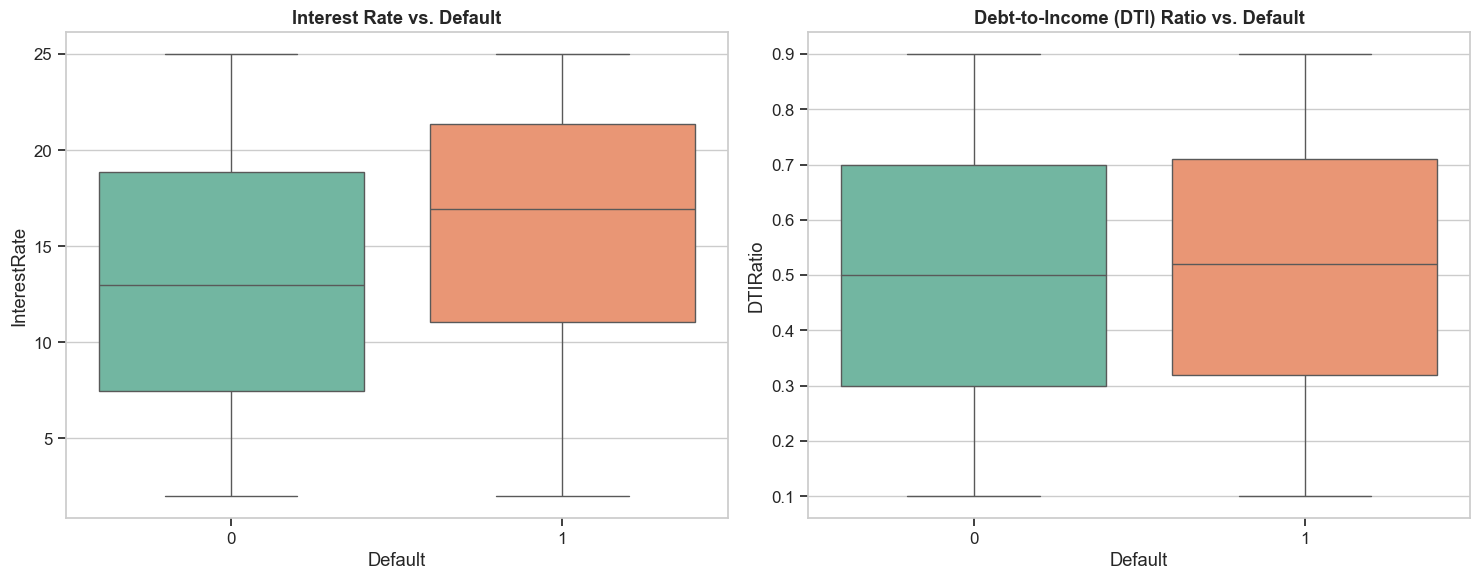

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='Default', y='InterestRate', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Interest Rate vs. Default', fontweight='bold')

sns.boxplot(x='Default', y='DTIRatio', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Debt-to-Income (DTI) Ratio vs. Default', fontweight='bold')

plt.tight_layout()
plt.show()

Questions Answered & Business Insights

5. Risk Indicators (Boxplots)
Question: Do defaulters have a systematically higher Interest Rate or Debt-to-Income (DTI) ratio? Are there outliers skewing our data?

Insight: Based on the boxplots, here is the analysis of your key risk indicators:

### 1. Interest Rate vs. Default

Defaulters (`1`) have a **systematically higher interest rate**.

* The median interest rate for defaulters is around **17%**, notably higher than the median of roughly **13%** for non-defaulters.
* The entire interquartile range (the orange box) is shifted upward, indicating that higher borrowing costs are heavily concentrated among those who default.

### 2. Debt-to-Income (DTI) Ratio vs. Default

Surprisingly, there is **almost no systemic difference** in the DTI ratio distributions between the two groups.

* The medians (around **0.50** for non-defaulters vs. **0.52** for defaulters) and the overall spreads of the boxes are nearly identical.
* While a high DTI is traditionally a risk factor, in this specific dataset, DTI on its own does not linearly differentiate a defaulter from a safe borrower.

### 3. Outliers

There are **no visible outliers** plotted as individual points beyond the whiskers in either chart. The data points for both metrics perfectly fill out the maximum and minimum ranges (e.g., interest rates from 2% to 25%, and DTI ratios from 0.1 to 0.9), meaning the whiskers extend to the actual minimum and maximum values without any extreme data anomalies skewing the visualization.